# Playground to manually test a few architectures/hyperparameters
## Train LSTM pipeline and plot rolling forecasts for test profiles

In [1]:
from pathlib import Path

from rabl.machine_learning.lstm_pipeline import (
    LSTMPipeline,
    LSTMPipelineConfig,
    test_and_save_forecasts,
    clear_cuda_cache,
)

In [4]:
batch_size = 256
epochs = 3
seed = 123
max_plots = 5

n_lstm = 2
lstm_hidden = 128              # shared across stacked layers
lstm_dropout = 0.3            # ignored if n_lstm == 1 in nn.LSTM

n_fc = 1
fc_hidden = (64,)

learning_rate = 1e-3
preload_training_data = True


h5_path = Path("../outputs/datasets/lstm_merged_batches_0001_k5_standard_train0.70_val0.15_test0.15.h5")
out_dir = Path("../outputs/ml_results/training_playground/")
out_dir.mkdir(parents=True, exist_ok=True)

print("h5_path exists:", h5_path.exists())
print("out_dir:", out_dir)

h5_path exists: True
out_dir: ..\outputs\ml_results\training_playground


In [6]:
config = LSTMPipelineConfig(
    h5_path=h5_path,
    batch_size=batch_size,
    seed=seed,
    n_lstm=n_lstm,
    lstm_hidden=lstm_hidden,
    lstm_dropout=lstm_dropout,
    n_fc=n_fc,
    fc_hidden=tuple(fc_hidden),
    learning_rate=learning_rate,
)

pipeline = LSTMPipeline(config)

datasets = pipeline.build()
pipeline.inspect()

Dataset summary:
  H5 path:         ..\outputs\datasets\lstm_merged_batches_0001_k5_standard_train0.70_val0.15_test0.15.h5
  Batch size:      256
  Seed:            123

  Train profiles:  700
  Val profiles:    150
  Test profiles:   150

  Sample X shape:  (2001, 6, 14)   (per-sample)
  Sample Y shape:  (2001, 13)   (per-sample)

  Train samples:   1,400,700  (~5,472 batches)
  Val samples:     300,150  (~1,173 batches)
  Test samples:    300,150  (profiles used for forecasting)

  loader cardinality (derived from precomputed counts):
    train:          5472
    val_samples:    1173
    val_profile_ds: 150
    test_profile_ds:150

Train batch X shape: torch.Size([256, 6, 14])
Train batch Y shape: torch.Size([256, 13])

Val profile: results_drum_profile_00008
  X profile shape: torch.Size([2001, 6, 14])
  Y profile shape: torch.Size([2001, 13])

Test profile: results_drum_profile_00004
  X profile shape: torch.Size([2001, 6, 14])
  Y profile shape: torch.Size([2001, 13])



Using GPU: NVIDIA GeForce RTX 4060 Ti

Deterministic seed set to: 123
LSTMRegressor architecture:
  Input features: 14
  LSTM layers (2): hidden_size=128, dropout=0.3
  FC layers (1): [64]
  Output targets: 13



Preloading train batches: 5472batch [00:09, 554.37batch/s]


Preloaded 5472 training batches to cuda:0 in 9.88s.


Train 1/3: 100%|████████████████████████████████████████████████| 5472/5472 [00:15<00:00, 353.64batch/s, loss=0.006237]
Val 1/3: 1173batch [00:03, 329.51batch/s]


Epoch 1/3 - loss: 0.023418 - val_loss: 0.081176 - data_wait: 0.07s - h2d: 0.00s - compute: 12.99s - val_time: 3.56s - preloaded: True - preload_time: 9.88s - max_cuda_mem: 615.77 MB


Train 2/3: 100%|████████████████████████████████████████████████| 5472/5472 [00:15<00:00, 353.64batch/s, loss=0.005813]
Val 2/3: 1173batch [00:03, 333.16batch/s]


Epoch 2/3 - loss: 0.007428 - val_loss: 0.066130 - data_wait: 0.07s - h2d: 0.00s - compute: 12.95s - val_time: 3.52s - preloaded: True - preload_time: 9.88s - max_cuda_mem: 615.77 MB


Train 3/3: 100%|████████████████████████████████████████████████| 5472/5472 [00:15<00:00, 346.58batch/s, loss=0.001070]
Val 3/3: 1173batch [00:03, 310.17batch/s]


Epoch 3/3 - loss: 0.005880 - val_loss: 0.015156 - data_wait: 0.07s - h2d: 0.00s - compute: 13.21s - val_time: 3.78s - preloaded: True - preload_time: 9.88s - max_cuda_mem: 615.77 MB
Saved training curves to ..\outputs\ml_results\training_playground\lstm_train_val_curve.png

Timing summary (cumulative):
  preload_time: 9.88s
  train_data_wait_time: 0.22s
  train_h2d_time: 0.00s
  train_compute_time: 39.15s
  train_epoch_time_total: 39.36s
  val_time_total: 10.87s
  estimated_total_time: 60.11s
Finished training using device: cuda:0


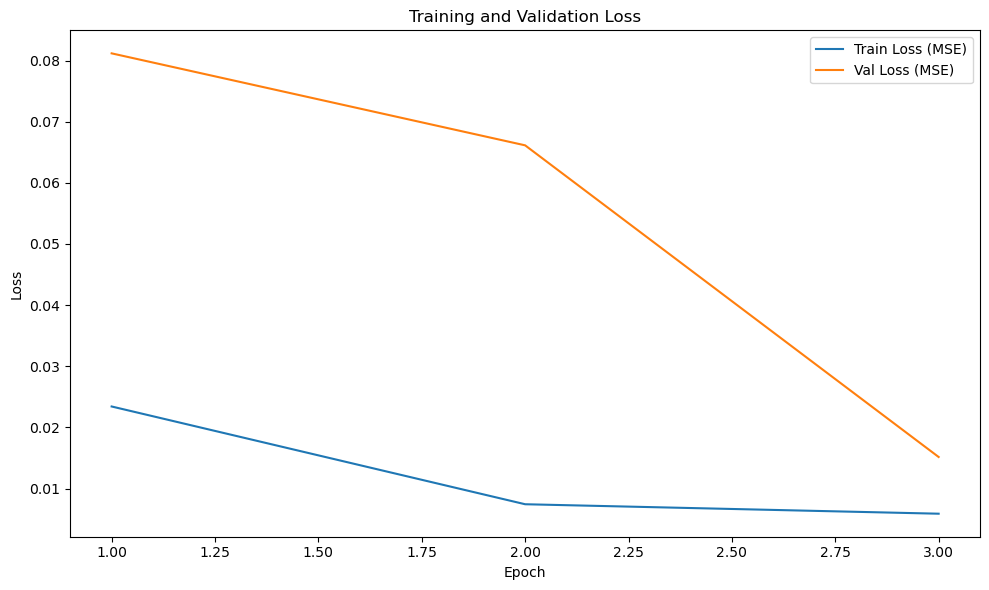

In [8]:
model, history, used_device = pipeline.train(epochs=epochs, out_dir=out_dir, preload_train_to_device=preload_training_data)
print(f"Finished training using device: {used_device}")

In [10]:
test_and_save_forecasts(
    model,
    datasets["test_profile_ds"],
    out_dir=out_dir,
    state_dim=pipeline.config.state_dim,
    control_channel=pipeline.config.control_channel,
    target_names=pipeline.config.target_names,
    max_plots=max_plots,
    plot_callback=pipeline.plot,
    h5_path=h5_path,
)

if "cuda" in str(used_device).lower():
    print(f"Clearing {used_device}...")
    del model
    clear_cuda_cache()

Forecast profiles: 1profile [00:02,  2.59s/profile, mse=9.124151e+09]

Saved forecast plot to: ..\outputs\ml_results\training_playground\rolling_forecast_results_drum_profile_00004.png


Forecast profiles: 2profile [00:05,  2.51s/profile, mse=2.346554e+09]

Saved forecast plot to: ..\outputs\ml_results\training_playground\rolling_forecast_results_drum_profile_00006.png


Forecast profiles: 3profile [00:07,  2.55s/profile, mse=3.130760e+09]

...

Saved forecast plot to: ..\outputs\ml_results\training_playground\rolling_forecast_results_drum_profile_00025.png


Forecast profiles: 5profile [00:12,  2.55s/profile, mse=3.602308e+09]

Saved forecast plot to: ..\outputs\ml_results\training_playground\rolling_forecast_results_drum_profile_00028.png


Forecast profiles: 150profile [02:53,  1.16s/profile, mse=4.371647e+08]


Testing timing summary: total_fetch: 0.0001s -  total_test: 165.4473s -  avg_fetch_profile: 0.0000s -  avg_inference_profile: 1.1030s -  save_time: 0.0509s

Clearing cuda:0...
